In [1]:
! pip install git+https://github.com/amazon-science/chronos-forecasting.git

  Cloning https://github.com/amazon-science/chronos-forecasting.git to /private/var/folders/ck/9102qxqx7cb0nzwzg4my5wh00000gn/T/pip-req-build-6clstvst
  Running command git clone --filter=blob:none --quiet https://github.com/amazon-science/chronos-forecasting.git /private/var/folders/ck/9102qxqx7cb0nzwzg4my5wh00000gn/T/pip-req-build-6clstvst
  Resolved https://github.com/amazon-science/chronos-forecasting.git to commit 6d68ed7c4ed2805d122d77b4660765b4089de5ca
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


RMSE: 102.66
MAPE: 0.77%


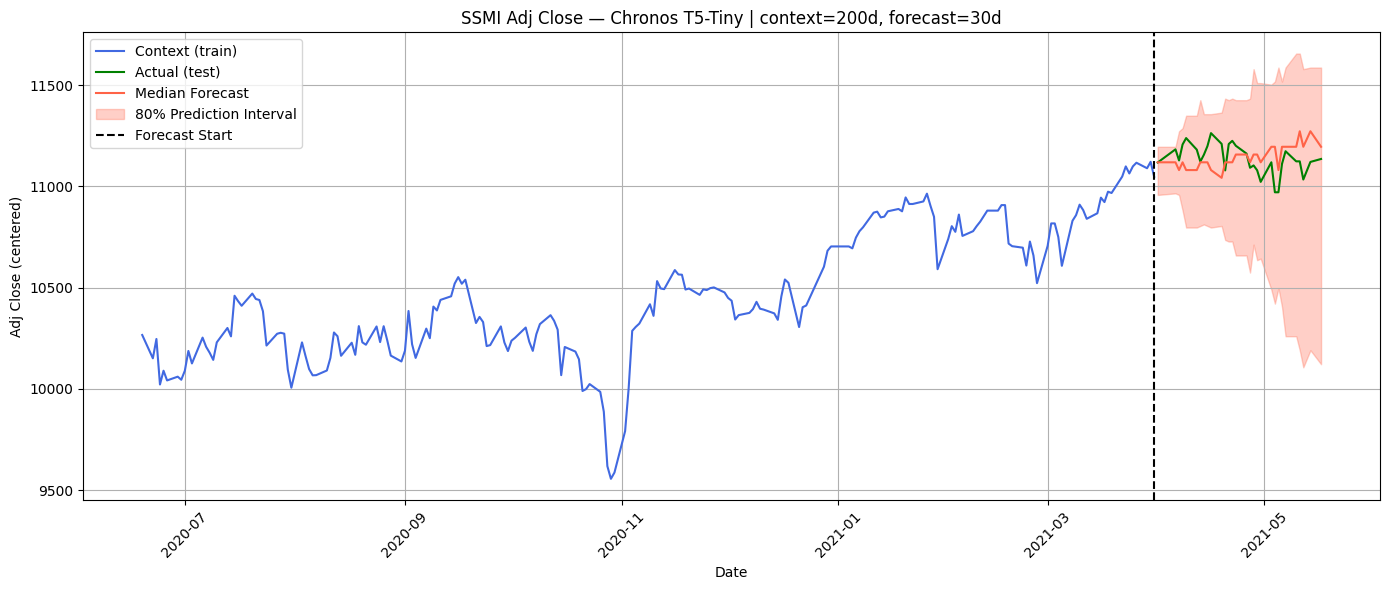

In [ ]:
import numpy as np
import pandas as pd
import torch
from chronos import ChronosPipeline
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# the data
df = pd.read_csv("/Users/ismaelbrahimbelhaouari/Documents/St Gallen University /Deep Learning/DLSuperSlay/DataSets/SSMI cleaned/SSMI_cleaned.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)


#Control window size
context_length    = 200  # past days fed to the model
prediction_length = 30   # days to forecast (keep <= 64)

total_window = context_length + prediction_length
df_window = df.tail(total_window).reset_index(drop=True)

y = df_window["Adj Close"].values.astype(float)

y_train = torch.tensor(y[:context_length], dtype=torch.float32)
y_test  = torch.tensor(y[context_length:], dtype=torch.float32)

# Load Chronos T5-tint or base or whatever 
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-base",
    device_map="cpu",
    torch_dtype=torch.float32,
)


#Forecast
forecast = pipeline.predict(
    y_train,                         
    prediction_length=prediction_length,
    num_samples=20,
)

# Metrics
median_forecast = np.median(forecast[0].numpy(), axis=0)
rmse = np.sqrt(mean_squared_error(y_test.numpy(), median_forecast))
mape = mean_absolute_percentage_error(y_test.numpy(), median_forecast) * 100
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# plot 
dates      = df_window["Date"].values
test_dates = dates[context_length:context_length + prediction_length]

low, median, high = np.quantile(forecast[0].numpy(), [0.1, 0.5, 0.9], axis=0)

plt.figure(figsize=(14, 6))
plt.plot(dates[:context_length], y[:context_length], color="royalblue", label="Context (train)")
plt.plot(dates[context_length:], y[context_length:], color="green",     label="Actual (test)")
plt.plot(test_dates, median,                          color="tomato",    label="Median Forecast")
plt.fill_between(test_dates, low, high, color="tomato", alpha=0.3,       label="80% Prediction Interval")
plt.axvline(x=dates[context_length - 1], color="black", linestyle="--", label="Forecast Start")

plt.legend()
plt.grid()
plt.xlabel("Date")
plt.ylabel("Adj Close (centered)")
plt.title(f"SSMI Adj Close — Chronos T5-Tiny | context={context_length}d, forecast={prediction_length}d")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()